# Test Audio2Text

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
META_RESULT = "../data/audio/meta_result.csv"
WHISPER_RESULT = "../data/audio/whisper_result.csv"
models = ['meta', 'whisper']
colors= ['gray', 'blue']

In [5]:
df1 = pd.read_csv(META_RESULT)
df1['model'] = 'meta'
df2 = pd.read_csv(WHISPER_RESULT)
df2['model'] = 'whisper'

df = pd.concat([df1, df2], sort=False)

In [6]:
df.columns

Index(['Unnamed: 0', 'INDICE', 'CODICE_INTERVENTO', 'COMMESSA', 'COD_CLIENTE',
       'DES_CLIENTE', 'DES_TIPO_FATT', 'TECNICO', 'TECNICO_TEL',
       'TECNICO_MOBILE', 'DATA_INTERVENTO', 'GIORNO_UOMO', 'ORE_ORDINARIE',
       'ORE_STRAORDINARIE', 'ORE_VIAGGIO', 'INEFFICIENCY', 'INEFFICIENCY_TYPE',
       'HOURS_BY_CLIENT', 'LN_ORDER', 'MATR', 'NOTE', 'MESSAGGIO', 'LANGUAGE',
       'TRANSCRIPT_META', 'CER_META', 'DURATION', 'model'],
      dtype='object')

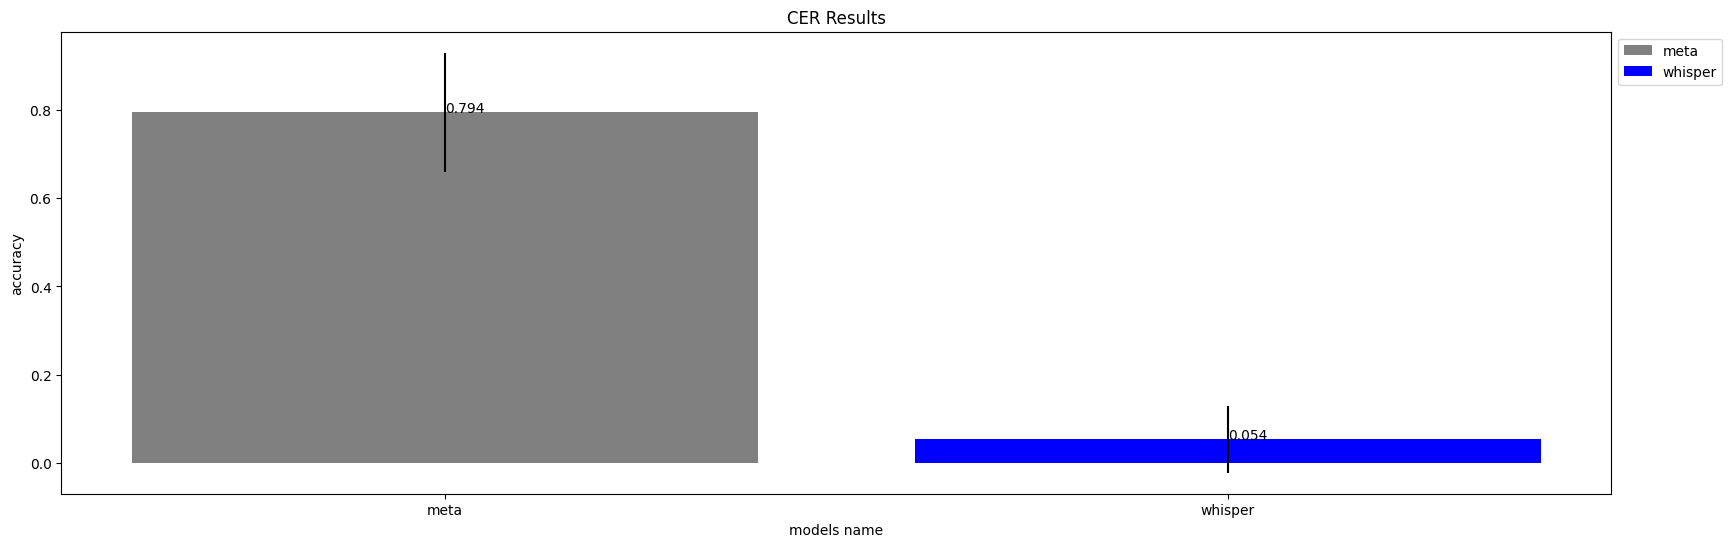

In [9]:
# show CER results
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[(df['model'] == model)]['CER_META'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors, label=models)
add_labels(models,media_group)
plt.title("CER Results")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

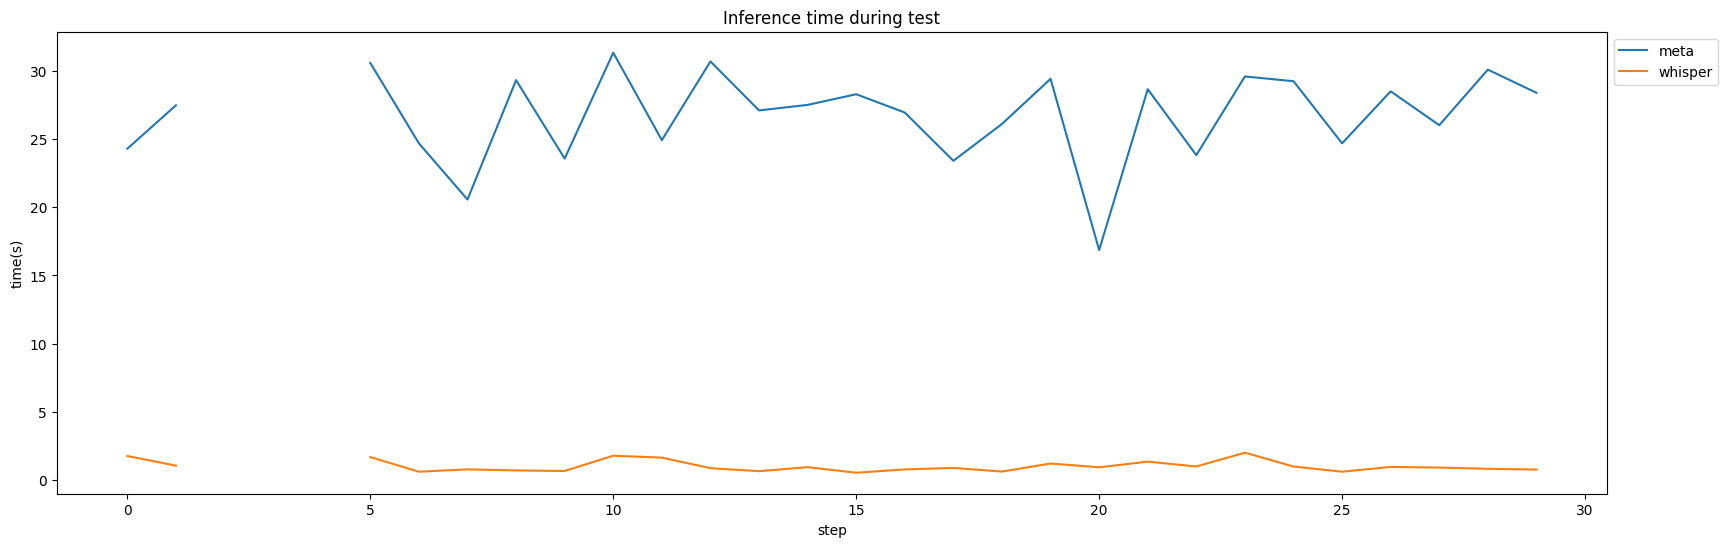

In [27]:
# plot duration results 

model_results = {}
for model in models:
    model_results[model] = round(df.loc[(df['model'] == model)]['DURATION'],3)

plt.figure(figsize=(20,6))
for model in models:
    plt.plot(model_results[model], label=model)
plt.title("Inference time during test")
plt.xlabel("step")
plt.ylabel("time(s)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))